In [255]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import factorial
import scipy.linalg as la
import statistics
import pandas as pd

In [ ]:
# Main block causing problems rn - tan/arctan or tanh/arctanh?

# Calculate C from Y using arctan
def C_from_Y(Y):
    #return (np.arctan(Y) + (np.pi / 2)) / np.pi
    return 0.5 * (1 + np.tanh(Y))

# Calculate Y from C using tan
def Y_from_C(C, eps=1e-12):
    C = np.clip(C, eps, 1.0 - eps)
    #return np.tan((np.pi * C) - (np.pi / 2))
    return np.arctanh(2*C - 1)

In [ ]:
# Simulate OU on latent Y_t with Euler–Maruyama, then map to C_t in (0,1)
    # dY_t = theta*(nu - Y_t) dt + sigma dW_t
    # C_t  = (1 + tanh(Y_t))/2

def simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N, rng=None):
    
    # nu is the long-term mean of Y_t, approximated by tan transforming mu
    nu = Y_from_C(mu)

    if rng is None:
        rng = np.random.default_rng()

    dt = T / N
    t = np.linspace(0.0, T, N + 1)

    Y = np.empty(N + 1, dtype=float)
    C = np.empty(N + 1, dtype=float)

    Y[0] = Y_from_C(C0)
    C[0] = C0

    for n in range(N):
        eta = rng.standard_normal()
        Y[n + 1] = Y[n] + theta * (nu - Y[n]) * dt + sigma * np.sqrt(dt) * eta   
        C[n + 1] = C_from_Y(Y[n + 1])

    return t, C, Y

In [ ]:
# tau = inf{t >= 0 : C_t <= Ccrit}, estimated from discrete samples
# Returns np.inf if no crossing on [0,T]

def first_passage_time(t, C, Ccrit, use_linear_interp=True):
    
    if C[0] <= Ccrit:
        return t[0]

    for n in range(len(t) - 1):
        if (C[n] > Ccrit) and (C[n + 1] <= Ccrit):
            if not use_linear_interp:
                return t[n + 1]

            # Linear interpolation for a better crossing estimate
            denom = (C[n + 1] - C[n])
            if denom == 0:
                return t[n + 1]
            alpha = (Ccrit - C[n]) / denom
            return t[n] + alpha * (t[n + 1] - t[n])

    return np.inf

In [ ]:
# Monte Carlo estimates for:
      # - E[tau]
      # - P(tau > T)
      # - optional survival curve S(t) = P(tau > t)

def monte_carlo_lifetime(
    Nr, C0, Ccrit, T, N,
    mu, theta, sigma,
    compute_survival_curve=True,
    rng=None
):
    
    if rng is None:
        rng = np.random.default_rng()

    t_grid = np.linspace(0.0, T, N + 1)
    taus = np.empty(Nr, dtype=float)

    for k in range(Nr):
        t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N, rng=rng)
        taus[k] = first_passage_time(t, C, Ccrit, use_linear_interp=True)

    # Estimates
    finite_taus = taus[np.isfinite(taus)]
    E_tau_hat = np.mean(finite_taus) if len(finite_taus) > 0 else np.inf
    P_survive_T_hat = np.mean(taus > T)   # tau=inf counts as surviving beyond T

    results = {
        "t_grid": t_grid,
        "taus": taus,
        "E_tau_hat": E_tau_hat,
        "P_survive_T_hat": P_survive_T_hat
    }

    if compute_survival_curve:
        S = np.array([np.mean(taus > tt) for tt in t_grid])
        results["survival_curve"] = S

    return results

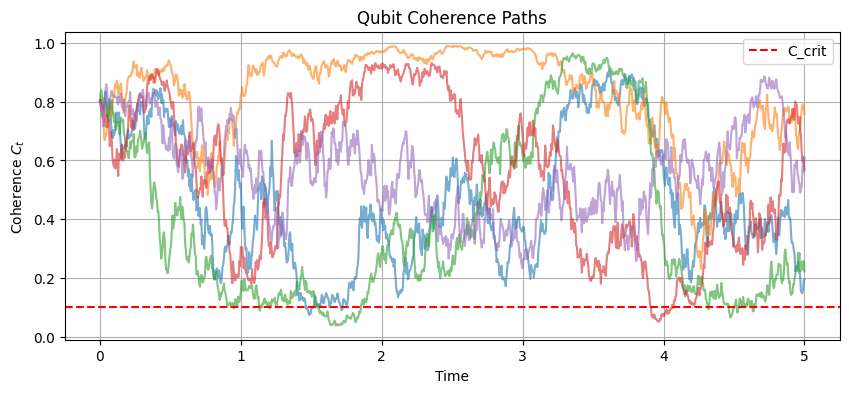

In [260]:
# Coherence Paths (C_t)
Ccrit = 0.1
C0 = 0.8
mu = 0.5 
theta = 1
sigma = 1
T = 5
N = 1000
Nr_paths = 5   # number of paths to visualize

plt.figure(figsize=(10,4))

for _ in range(Nr_paths):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    plt.plot(t, C, alpha=0.6)

plt.axhline(Ccrit, color='red', linestyle='--', label='C_crit')

plt.title("Qubit Coherence Paths")
plt.xlabel("Time")
plt.ylabel("Coherence $C_t$")
plt.grid(True)
plt.legend()

plt.show()

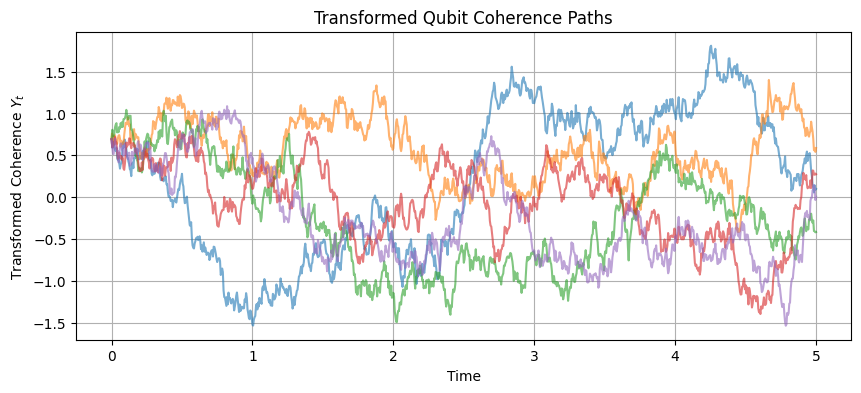

In [261]:
# Transformed Coherence Paths (Y_t)
plt.figure(figsize=(10,4))

for _ in range(Nr_paths):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    plt.plot(t, Y, alpha=0.6)

#plt.axhline(Ccrit, color='red', linestyle='--', label='C_crit')

plt.title("Transformed Qubit Coherence Paths")
plt.xlabel("Time")
plt.ylabel("Transformed Coherence $Y_t$")
plt.grid(True)

plt.show()

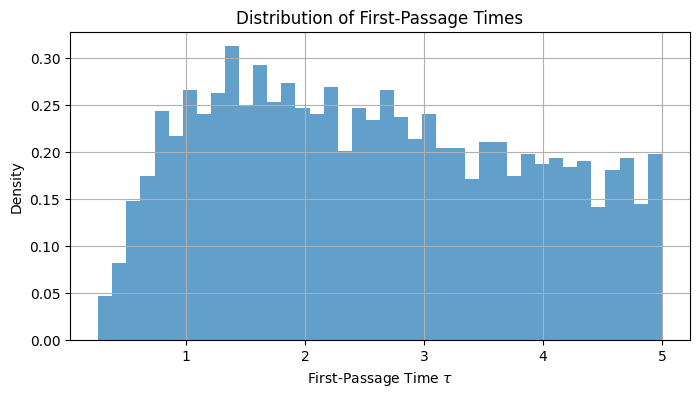

In [262]:
# Histogram for first time passages
results = monte_carlo_lifetime(
    Nr=5000,
    C0=C0,
    Ccrit=Ccrit,
    T=T,
    N=N,
    mu=mu,
    theta=theta,
    sigma=sigma
)

taus = results["taus"]
finite_taus = taus[np.isfinite(taus)]

plt.figure(figsize=(8,4))

plt.hist(finite_taus, bins=40, density=True, alpha=0.7)

plt.title("Distribution of First-Passage Times")
plt.xlabel("First-Passage Time $\\tau$")
plt.ylabel("Density")
plt.grid(True)

plt.show()

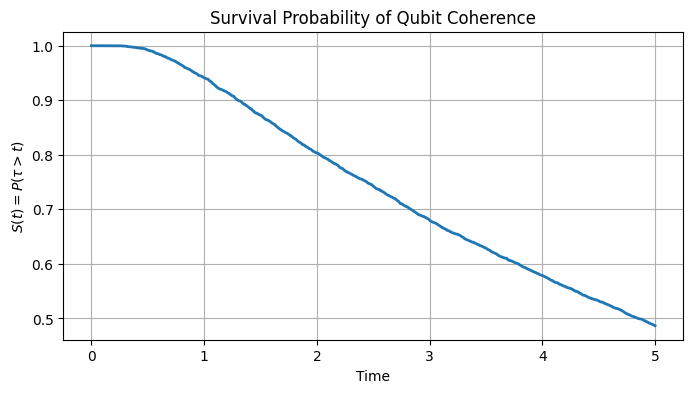

In [ ]:
# Survival Probability Curve
t_grid = results["t_grid"]
S = results["survival_curve"]

plt.figure(figsize=(8,4))

plt.plot(t_grid, S, linewidth=2)

plt.title("Survival Probability of Qubit Coherence")
plt.xlabel("Time")
plt.ylabel("$S(t) = P(\\tau > t)$")
plt.grid(True)

plt.show()

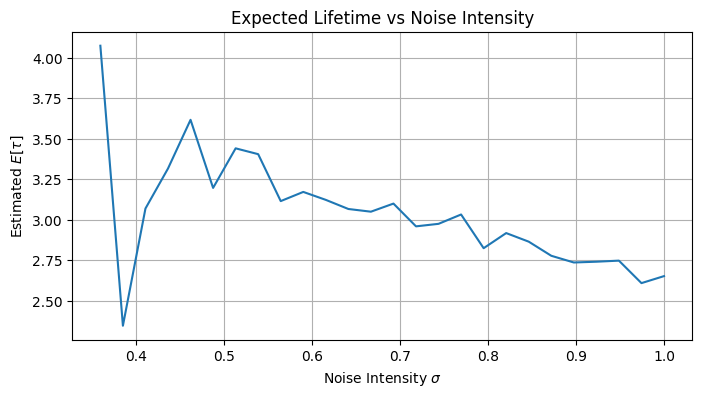

In [264]:
# Effect of Noise Intensity (different sigmas)
sigma_vals = np.linspace(0,1,40)
E_tau_vals = []

for s in sigma_vals:
    res = monte_carlo_lifetime(
        Nr=2000,
        C0=C0,
        Ccrit=Ccrit,
        T=T,
        N=N,
        mu=mu,
        theta=theta,
        sigma=s
    )
    E_tau_vals.append(res["E_tau_hat"])

plt.figure(figsize=(8,4))

plt.plot(sigma_vals, E_tau_vals)

plt.title("Expected Lifetime vs Noise Intensity")
plt.xlabel("Noise Intensity $\\sigma$")
plt.ylabel("Estimated $E[\\tau]$")
plt.grid(True)

plt.show()